# NB1_DataEngineering_Colab_TestRun
HF project: `boods/FrMedQA-CrossLingual-v2-PPL-<qlora|bf16>-*`
Path: `/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2`


In [ ]:
# ⚙️ Stage 0 — Install dependencies (Colab)
import subprocess, sys, importlib

REQUIRED = {"unsloth":"unsloth","transformers":"transformers","peft":"peft",
            "bitsandbytes":"bitsandbytes","datasets":"datasets",
            "rouge_score":"rouge-score","nltk":"nltk","bert_score":"bert-score",
            "huggingface_hub":"huggingface-hub","tqdm":"tqdm",
            "sklearn":"scikit-learn","sacrebleu":"sacrebleu", "modelscope": "modelscope",
            "datasketch": "datasketch"}

missing_pkgs_to_install = []
for mod, pkg in REQUIRED.items():
    if importlib.util.find_spec(mod) is None:
        missing_pkgs_to_install.append(pkg)

if missing_pkgs_to_install:
    print(f"Attempting to install missing packages: {missing_pkgs_to_install}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_pkgs_to_install)
        print("Successfully installed missing packages. A kernel restart is recommended for full effect.")
    except subprocess.CalledProcessError as e:
        print(f"Error during installation of {missing_pkgs_to_install}: {e}. Please install manually.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during package installation: {e}")
        raise

try:
    import nltk
    nltk.download("punkt_tab", quiet=True)
    nltk.download("punkt", quiet=True)
except Exception:
    pass
print("✓ Stage 0 done")


In [ ]:
# ⚙️ Stage 0b — Drive mount, paths, secrets
import os, sys

def _on_colab():
    try:
        import google.colab; return True
    except Exception: return False

if _on_colab():
    from google.colab import drive
    drive.mount("/content/drive")

    def _secret(name, prompt):
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v: return v
        except Exception: pass
        import getpass
        return getpass.getpass(prompt)
    os.environ["HF_TOKEN"] = _secret("HF_TOKEN", "HF_TOKEN: ")
    _wb = _secret("WANDB_API_KEY", "WANDB_API_KEY (blank to skip): ")
    if _wb:
        os.environ["WANDB_API_KEY"] = _wb
    else:
        os.environ["WANDB_DISABLED"] = "true"

BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
REPO_DIR    = BASE_DIR
RESULTS_DIR = os.path.join(BASE_DIR, "RESULT")
EVALS_DIR   = os.path.join(BASE_DIR, "EVALS")
CACHE_DIR   = os.path.join(EVALS_DIR, "results_cache")
OUT_DIR     = os.path.join(BASE_DIR, "analysis_output")
FIG_DIR     = os.path.join(OUT_DIR, "figures")
for d in (RESULTS_DIR, EVALS_DIR, CACHE_DIR, OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["FRMEDQA_REPO"] = REPO_DIR
os.environ["FRMEDQA_BASE"] = BASE_DIR
os.environ["FRMEDQA_HF_USER"] = "boods"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

for v in ("HF_HOME", "HF_HUB_CACHE", "TRANSFORMERS_CACHE", "HUGGINGFACE_HUB_CACHE"):
    os.environ[v] = os.path.join(BASE_DIR, "hf_cache")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")


In [ ]:
os.environ["FRMEDQA_PROJECT_NAME"] = "FrMedQA-CrossLingual-v2-PPL"
if os.environ.get("FRMEDQA_SEED"):   # cluster multi-seed run: one HF namespace per seed
    os.environ["FRMEDQA_PROJECT_NAME"] += f"-s{os.environ['FRMEDQA_SEED']}"
print(f"HF project: {os.environ['FRMEDQA_PROJECT_NAME']}")


In [ ]:
# Stage 0d — Reuse the v1 data splits in the new v2 folder (recommended).
# Copies train/val/test/exemplars from the old project folder so the v2 models
# are evaluated on the SAME test items as before. If this copies the files,
# the rest of NB1 can be skipped. Set REUSE_V1_SPLITS = False to rebuild.
import shutil
REUSE_V1_SPLITS = True
V1_RESULT = "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT"
_files = ["train.jsonl", "val.jsonl", "test.jsonl", "exemplars.jsonl",
          "dapt_corpus_sample.jsonl", "data_stats.json", "leakage_report.json"]
if REUSE_V1_SPLITS and os.path.isdir(V1_RESULT):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    for _f in _files:
        _src = os.path.join(V1_RESULT, _f)
        if os.path.exists(_src) and not os.path.exists(os.path.join(RESULTS_DIR, _f)):
            shutil.copy2(_src, RESULTS_DIR); print(f"  copied {_f}")
    print(f"✓ v1 splits available in {RESULTS_DIR} — the remaining NB1 cells can be skipped")
else:
    print("Building splits from scratch (run all NB1 cells).")


# NB1_DataEngineering (Colab Test Run)
Run the **Colab bootstrap** cell first. All HF repos use `FrMedQA-CrossLingual-v2-PPL`.

# 📓 NB1 — Data Engineering & Leakage Shield**EnToFrMedicaLLM pipeline · Notebook 1 of 6**
This notebook is the **foundation** of the entire pipeline. It produces four artifactsthat every downstream notebook (NB2–NB6) consumes:|
 File | Purpose |
 |------|---------|
 | `train.jsonl` | Training data for SFT (MCQA + ExtQA + AbsQA) |
 | `val.jsonl`   | Validation data (held out from train, used for early stopping) |
 | `test.jsonl`  | **Golden Test Set** — locked, never seen during training |
 | `exemplars.jsonl` | Few-shot exemplar pool (separate from train AND test) |
 ### The Leakage ShieldWe use **MinHash + LSH** to detect and remove any training samples that overlap withthe test set.
 This is non-negotiable: leakage invalidates the entire benchmark.
 ### Three subtasks loaded
 - **MCQA**: `qanastek/frenchmedmcqa` (DEFT-2023, train/dev/test)
 - **ExtQA**: derived from `Dr-BERT/QUAERO` (medline + emea), span-extraction format
 - **AbsQA**: `ANR-MALADES/MediQAl` (open-ended French medical questions)
 ### Outputs land in`{cfg.results_dir}/` (= `/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2/RESULT/`)

## ⚙️ Stage 0 — Install dependencies (only if missing)

## 🔑 Stage 1 — Boilerplate, paths, config, logger

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Stage 1a: Mount Drive (Colab only) and ensure base directory exists
# ──────────────────────────────────────────────────────────────────────
import os, sys

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive", force_remount=False)
    print("✓ Drive mounted")
else:
    print("• Non-Colab environment — using local paths")

Mounted at /content/drive
✓ Drive mounted


In [5]:
# Stage 1 — import shared modules (cluster-ready)
#   Code (enmed_core / enmed_recipe) comes from the cloned repo + `poetry install`.
#   DATA & OUTPUTS live under $FRMEDQA_BASE (point it at scratch). Code != data.
import os, sys
BASE_DIR = os.environ.get("FRMEDQA_BASE", os.path.expanduser("~/frmedqa_experiments"))
def _find_repo_on_path():
    try:
        import enmed_core  # already importable (cwd = repo root, or installed)
        return
    except ModuleNotFoundError:
        for cand in [os.environ.get("FRMEDQA_REPO"), os.getcwd(),
                     os.path.abspath(os.path.join(os.getcwd(), ".."))]:
            if cand and os.path.exists(os.path.join(cand, "enmed_core.py")):
                sys.path.insert(0, cand); return
        raise ModuleNotFoundError("enmed_core not found — run `poetry install` in the repo, launch Jupyter from the repo root, or set $FRMEDQA_REPO to the repo path.")
_find_repo_on_path()
import enmed_core as ec
print(f"✓ enmed_core imported | BASE_DIR = {BASE_DIR}")

✓ Imported enmed_core from /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/MODEL_TRAINING


In [6]:
# ──────────────────────────────────────────────────────────────────────
# Stage 1c: Build config + logger + seed everything
# ──────────────────────────────────────────────────────────────────────
cfg = ec.EnMedConfig(
    base_dir = BASE_DIR,
    seed     = 42,
    # NB1-specific overrides if any:
    minhash_threshold = 0.8,
    minhash_num_perm  = 128,
    exemplar_pool_size_per_task = 200,
)
cfg.make_dirs()

logger = ec.setup_logger(
    name = "nb1",
    log_file = os.path.join(cfg.results_dir, f"nb1_{ec.now_ts()}.log"),
)

ec.seed_all(cfg.seed)
ec.colab_keep_alive()

logger.info("=" * 70)
logger.info(f"NB1 — Data Engineering & Leakage Shield")
logger.info(f"  base_dir    : {cfg.base_dir}")
logger.info(f"  results_dir : {cfg.results_dir}")
logger.info(f"  cache_dir   : {cfg.cache_dir}")
logger.info(f"  seed        : {cfg.seed}")
logger.info("=" * 70)

# Persist the config for reproducibility
cfg_path = cfg.save()
logger.info(f"✓ Config saved to {cfg_path}")

<IPython.core.display.Javascript object>

04:00:42 | I | ======================================================================
04:00:42 | I | NB1 — Data Engineering & Leakage Shield
04:00:42 | I |   base_dir    : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26
04:00:42 | I |   results_dir : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT
04:00:42 | I |   cache_dir   : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/hf_cache
04:00:42 | I |   seed        : 42
04:00:42 | I | ======================================================================
04:00:42 | I | ✓ Config saved to /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/MODEL_TRAINING/config.json


## 🔐 Stage 2 — Hugging Face authentication

In [8]:
# ──────────────────────────────────────────────────────────────────────
# Stage 2: HF auth. We need this to download MCQA + AbsQA datasets.
# If HF_TOKEN is missing we still try public datasets but warn loudly.
# ──────────────────────────────────────────────────────────────────────
HF_TOKEN = ec.bootstrap_hf(logger=logger)
HF_USER  = cfg.hf_user

if not HF_TOKEN:
    logger.warning("⚠ HF_TOKEN missing — gated datasets (PARCOMED, MediQAl) may fail")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


04:01:21 | I | ✓ HF authenticated


## 🥇 Stage 3 — Load Golden Test SetsThese three test sets are **locked**: NB2–NB6 evaluate on them and never see themduring training. Stage 5's MinHash shield enforces this invariant.We support multiple dataset IDs as fallbacks because some HF repos have movedor been renamed.

In [9]:
# ──────────────────────────────────────────────────────────────────────
# Stage 3a: MCQA test set — qanastek/frenchmedmcqa (DEFT-2023)
# Format: zipped JSON files (train.json, dev.json, test.json)
# Each row: {id, question, answers: {A,B,C,D,E}, correct_answers, ...}
# ──────────────────────────────────────────────────────────────────────
import zipfile
from huggingface_hub import hf_hub_download
from datasets import load_dataset, DatasetDict

mcqa_test_rows = []
mcqa_train_rows = []
mcqa_val_rows = []

try:
    zip_path = hf_hub_download(
        repo_id   = "qanastek/frenchmedmcqa",
        filename  = "DEFT-2023-FULL.zip",
        repo_type = "dataset",
        cache_dir = cfg.cache_dir,
        token     = HF_TOKEN,
    )
    extract_to = os.path.join(cfg.cache_dir, "frenchmedmcqa_extracted")
    if not os.path.exists(os.path.join(extract_to, "test.json")):
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(extract_to)

    import json
    for split, fn in [("train", "train.json"), ("dev", "dev.json"), ("test", "test.json")]:
        path = os.path.join(extract_to, fn)
        with open(path, "r", encoding="utf-8") as f:
            rows = json.load(f)
        if split == "train":
            mcqa_train_rows = rows
        elif split == "dev":
            mcqa_val_rows = rows
        else:
            mcqa_test_rows = rows

    logger.info(f"  MCQA train : {len(mcqa_train_rows):,}")
    logger.info(f"  MCQA val   : {len(mcqa_val_rows):,}")
    logger.info(f"  MCQA test  : {len(mcqa_test_rows):,}  ← Golden")
except Exception as e:
    logger.error(f"✗ MCQA load failed: {e}")
    raise

DEFT-2023-FULL.zip:   0%|          | 0.00/550k [00:00<?, ?B/s]

04:03:01 | I |   MCQA train : 2,171
04:03:01 | I |   MCQA val   : 312
04:03:01 | I |   MCQA test  : 622  ← Golden


In [11]:
# ──────────────────────────────────────────────────────────────────────
# Stage 3b: AbsQA — ANR-MALADES/MediQAl (open-ended)
# Each row: {question, short_answer, long_answer, ...}
# ──────────────────────────────────────────────────────────────────────
absqa_test_rows = []
absqa_train_rows = []

# MediQAl has multiple subsets — 'oeq' is open-ended; 'mcq' is the multi-choice
# variant. We use 'oeq' for AbsQA.
ABSQA_CANDIDATES = [
    ("ANR-MALADES/MediQAl", "oeq"),
    ("ANR-MALADES/MEDIQA-l", "oeq"),
    ("DrBenchmark/MEDIQAL",  None),
]

absqa_ds = None
for ds_id, subset in ABSQA_CANDIDATES:
    current_ds = None
    try:
        if subset:
            current_ds = load_dataset(ds_id, subset, cache_dir=cfg.cache_dir, token=HF_TOKEN)
        else:
            current_ds = load_dataset(ds_id, cache_dir=cfg.cache_dir, token=HF_TOKEN)

        # Relaxed check: Accept the dataset as long as it loaded successfully
        if len(current_ds.keys()) > 0:
            absqa_ds = current_ds
            logger.info(f"✓ Loaded AbsQA from {ds_id} (subset={subset})")
            break

    except Exception as e:
        logger.warning(f"  {ds_id}/{subset} failed: {e}")

if absqa_ds is None:
    raise RuntimeError("Could not load any MediQAl variant. Check HF token + dataset access.")

# Pick splits
def _list_split(ds, name):
    return list(ds[name]) if name in ds else []

absqa_train_rows = _list_split(absqa_ds, "train")
absqa_val_rows   = _list_split(absqa_ds, "val") or _list_split(absqa_ds, "dev")
absqa_test_rows  = _list_split(absqa_ds, "test")

import random as _r
rng = _r.Random(cfg.seed)

# NEW: If there's ONLY a test split (like MediQAl 'oeq'), split it into train/val/test
if not absqa_train_rows and absqa_test_rows:
    shuffled = absqa_test_rows.copy()
    rng.shuffle(shuffled)
    n_test = max(50, len(shuffled) // 20) # Reserve 5% for testing
    n_val = max(50, len(shuffled) // 10)  # Reserve 10% for validation
    absqa_test_rows = shuffled[:n_test]
    absqa_val_rows = shuffled[n_test:n_test + n_val]
    absqa_train_rows = shuffled[n_test + n_val:]
    logger.warning(f"  No train/val split found — carved out {len(absqa_train_rows):,} train and {len(absqa_val_rows):,} val rows from the test split")

# ORIGINAL FALLBACK: If no separate test split, hold out 10% of train as test
elif not absqa_test_rows and absqa_train_rows:
    shuffled = absqa_train_rows.copy()
    rng.shuffle(shuffled)
    n_test = max(50, len(shuffled) // 10)
    absqa_test_rows = shuffled[:n_test]
    absqa_train_rows = shuffled[n_test:]
    logger.warning(f"  No test split — held out {n_test} from train")

logger.info(f"  AbsQA train : {len(absqa_train_rows):,}")
logger.info(f"  AbsQA val   : {len(absqa_val_rows):,}")
logger.info(f"  AbsQA test  : {len(absqa_test_rows):,}  ← Golden")

04:03:51 | I | ✓ Loaded AbsQA from ANR-MALADES/MediQAl (subset=oeq)
04:03:52 | W |   No train/val split found — carved out 4,225 train and 496 val rows from the test split
04:03:52 | I |   AbsQA train : 4,225
04:03:52 | I |   AbsQA val   : 496
04:03:52 | I |   AbsQA test  : 248  ← Golden


In [13]:
# ──────────────────────────────────────────────────────────────────────
# Stage 3c: ExtQA — derived from QUAERO French Medical (Dr-BERT/QUAERO)
# QUAERO has 'tokens' + entity tags. We synthesise span-extraction QA pairs.
# Strategy: for each annotated entity, ask "Quelle est la mention de
# {category} dans le texte ?" and gold-span = the entity surface form.
# ──────────────────────────────────────────────────────────────────────
extqa_train_rows = []
extqa_val_rows = []
extqa_test_rows = []

QUAERO_CANDIDATES = [
    ("Dr-BERT/QUAERO",     "medline"),
    ("Dr-BERT/QUAERO",     "emea"),
    ("DrBenchmark/QUAERO", "medline"),
    ("mnaguib/QuaeroFrenchMed", "medline"),
]

quaero_loaded = {}
for ds_id, subset in QUAERO_CANDIDATES:
    if subset in quaero_loaded:
        continue
    try:
        ds = load_dataset(ds_id, subset, cache_dir=cfg.cache_dir, token=HF_TOKEN)
        quaero_loaded[subset] = (ds_id, ds)
        logger.info(f"✓ QUAERO {subset} loaded from {ds_id}")
    except Exception as e:
        logger.warning(f"  {ds_id}/{subset} failed: {e}")

if not quaero_loaded:
    raise RuntimeError("All QUAERO sources failed.")

# QUAERO entity-tag → French question template
TAG2QUESTION = {
    "ANAT":  "Quelle structure anatomique est mentionn0e ?",
    "CHEM":  "Quel compos0 chimique ou m0dicament est mentionn0 ?",
    "DEVI":  "Quel dispositif m0dical est mentionn0 ?",
    "DISO":  "Quelle pathologie ou trouble est mentionn0 ?",
    "GEOG":  "Quel lieu g0ographique est mentionn0 ?",
    "LIVB":  "Quel organisme vivant est mentionn0 ?",
    "OBJC":  "Quel objet est mentionn0 ?",
    "PHEN":  "Quel ph0nom0ne biologique est mentionn0 ?",
    "PHYS":  "Quel processus physiologique est mentionn0 ?",
    "PROC":  "Quelle proc0dure m0dicale est mentionn0e ?",
}


def quaero_to_extqa(ds_split, source_label: str, max_per_split: int = 5000):
    """Convert QUAERO NER format → SQuAD-style extractive QA.

    QUAERO row: {tokens: [...], ner_tags: [...]}
    Output:     {context, question, answers: {text:[...], answer_start:[...]},
                 source, specialty}
    """
    rows = []
    label_names = ds_split.features["ner_tags"].feature.names if "ner_tags" in ds_split.features else None

    for ex in ds_split:
        if len(rows) >= max_per_split:
            break
        toks = ex.get("tokens", [])
        tags = ex.get("ner_tags", [])
        if not toks or not tags or len(toks) != len(tags):
            continue

        # Reconstruct context with character offsets
        context = ""
        offsets = []
        for tok in toks:
            offsets.append(len(context))
            context += str(tok) + " "
        context = context.rstrip()

        # Find entity spans (BIO tag scheme)
        i = 0
        while i < len(tags):
            tag_id = tags[i]
            tag_str = label_names[tag_id] if label_names else str(tag_id)
            if tag_str.startswith("B-"):
                cat = tag_str[2:]
                start_tok = i
                end_tok = i
                j = i + 1
                while j < len(tags):
                    nxt = label_names[tags[j]] if label_names else str(tags[j])
                    if nxt.startswith(f"I-{cat}"):
                        end_tok = j
                        j += 1
                    else:
                        break
                # Build span
                start_char = offsets[start_tok]
                end_char = offsets[end_tok] + len(str(toks[end_tok]))
                span_text = context[start_char:end_char]
                question = TAG2QUESTION.get(cat, f"Quelle entit0 de type {cat} est mentionn0e ?")

                rows.append({
                    "id": f"quaero_{source_label}_{len(rows)}",
                    "context": context,
                    "question": question,
                    "answers": {"text": [span_text], "answer_start": [start_char]},
                    "source": source_label,
                    "specialty": cat.lower(),
                })
                i = j
            else:
                i += 1
    return rows

temp_extqa_test_candidates = []
temp_extqa_val_candidates = []

for subset, (ds_id, ds) in quaero_loaded.items():
    for split_name in ds.keys():
        rows = quaero_to_extqa(ds[split_name], f"{subset}_{split_name}")
        if split_name in ("test",):
            temp_extqa_test_candidates.extend(rows)
        elif split_name in ("validation", "dev"):
            temp_extqa_val_candidates.extend(rows)
        else:
            extqa_train_rows.extend(rows)

import random as _r_extqa
rng_extqa = _r_extqa.Random(cfg.seed)

# Shuffle the test candidates to ensure randomness in selection
rng_extqa.shuffle(temp_extqa_test_candidates)

# Revert test percentage to 5%
target_test_percentage = 0.05
n_extqa_test = max(50, int(len(temp_extqa_test_candidates) * target_test_percentage))
extqa_test_rows = temp_extqa_test_candidates[:n_extqa_test]
extqa_train_rows.extend(temp_extqa_test_candidates[n_extqa_test:])

# Shuffle and reduce the validation candidates to augment training
rng_extqa.shuffle(temp_extqa_val_candidates)
target_val_percentage = 0.1 # Keep 10% for val, 90% goes to train
n_extqa_val = max(50, int(len(temp_extqa_val_candidates) * target_val_percentage))
extqa_val_rows = temp_extqa_val_candidates[:n_extqa_val]
extqa_train_rows.extend(temp_extqa_val_candidates[n_extqa_val:])

logger.info(f"  ExtQA train : {len(extqa_train_rows):,}")
logger.info(f"  ExtQA val   : {len(extqa_val_rows):,}  ← Reduced to augment train")
logger.info(f"  ExtQA test  : {len(extqa_test_rows):,}  ← Golden (re-proportioned to 5%)")


04:05:07 | I | ✓ QUAERO medline loaded from Dr-BERT/QUAERO
04:05:08 | I | ✓ QUAERO emea loaded from Dr-BERT/QUAERO
04:05:09 | I |   ExtQA train : 12,253
04:05:09 | I |   ExtQA val   : 416  ← Reduced to augment train
04:05:09 | I |   ExtQA test  : 207  ← Golden (re-proportioned to 5%)


## 📚 Stage 4 — Load training corpora for DAPT (NB2)The DAPT corpus is large unlabelled French medical text used by NB2 fordomain-adaptive pre-training. PARCOMED is the primary source; we add fallbacks.

In [14]:
# ──────────────────────────────────────────────────────────────────────
# Stage 4a: PARCOMED — French parallel medical corpus
# May be gated; we set strict=False so the notebook still completes if it
# fails (NB2 will then run on the fallbacks alone).
# ──────────────────────────────────────────────────────────────────────
PARCOMED_TARGET_N = 50_000     # cap for NB1 stats — NB2 streams the full set

parcomed_texts = []
parcomed_meta = {"loaded": False, "source": None, "n": 0}

try:
    pc = load_dataset(cfg.parcomed_id, split="train",
                      cache_dir=cfg.cache_dir, token=HF_TOKEN,
                      streaming=True)
    # Find first text-y column on the fly
    take_n = PARCOMED_TARGET_N
    for i, ex in enumerate(pc):
        if i >= take_n:
            break
        # Heuristic: pick longest string field
        candidates = [(k, v) for k, v in ex.items()
                      if isinstance(v, str) and len(v) > 50]
        if not candidates:
            continue
        candidates.sort(key=lambda kv: -len(kv[1]))
        parcomed_texts.append(candidates[0][1])
    parcomed_meta = {
        "loaded": True, "source": cfg.parcomed_id, "n": len(parcomed_texts),
    }
    logger.info(f"✓ PARCOMED: {len(parcomed_texts):,} texts (capped at {PARCOMED_TARGET_N:,} for NB1)")
except Exception as e:
    logger.warning(f"⚠ PARCOMED unavailable ({e}) — NB2 will use fallbacks only")

README.md: 0.00B [00:00, ?B/s]

04:05:48 | I | ✓ PARCOMED: 40,267 texts (capped at 50,000 for NB1)


In [15]:
# ──────────────────────────────────────────────────────────────────────
# Stage 4b: CAS corpus + Dr-BERT FrenchMedMCQA train (additional FR medical text)
# These provide redundancy for DAPT and allow ExtQA construction in NB6.
# ──────────────────────────────────────────────────────────────────────
fr_medical_texts = []   # for DAPT supplementation

# CAS — French clinical cases
for ds_id in ["DrBenchmark/CAS", "Dr-BERT/CAS"]:
    try:
        cas = load_dataset(ds_id, cache_dir=cfg.cache_dir, token=HF_TOKEN,
                           trust_remote_code=True)
        for split_name in cas.keys():
            for ex in cas[split_name]:
                # Reconstruct from tokens or pick text field
                if "tokens" in ex and isinstance(ex["tokens"], list) and ex["tokens"]:
                    txt = " ".join(str(t) for t in ex["tokens"])
                else:
                    txt = next((v for v in ex.values()
                                if isinstance(v, str) and len(v) > 40), "")
                if txt and len(txt) > 100:
                    fr_medical_texts.append(txt)
        logger.info(f"  CAS ({ds_id}): cumulative texts = {len(fr_medical_texts):,}")
        break
    except Exception as e:
        logger.warning(f"  {ds_id} unavailable: {e}")

logger.info(f"✓ FR medical texts loaded: {len(fr_medical_texts):,}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'DrBenchmark/CAS' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'DrBenchmark/CAS' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

pos/train-00000-of-00001.parquet:   0%|          | 0.00/458k [00:00<?, ?B/s]

pos/validation-00000-of-00001.parquet:   0%|          | 0.00/80.2k [00:00<?, ?B/s]

pos/test-00000-of-00001.parquet:   0%|          | 0.00/143k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2653 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/379 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/758 [00:00<?, ? examples/s]

04:06:29 | I |   CAS (DrBenchmark/CAS): cumulative texts = 2,171
04:06:29 | I | ✓ FR medical texts loaded: 2,171


## 🛡️ Stage 5 — Leakage Shield (MinHash + LSH)For each test set, we build a MinHashLSH index over the test questions/contexts.We then scan **every** training row and drop any that have a near-duplicate(Jaccard similarity ≥ 0.8) in the test index.This guards against:- Identical questions appearing in both train and test (FrenchMedMCQA has known overlaps)- Paraphrased duplicates- Same clinical case used in different splits**This step is mandatory and the most important quality gate in the entire pipeline.**

In [16]:
# ──────────────────────────────────────────────────────────────────────
# Stage 5a: Extract test "fingerprint texts" from each test set
# ──────────────────────────────────────────────────────────────────────
def _mcqa_fingerprint(ex):
    """Concatenate question + all answer choices for a strong fingerprint."""
    q = str(ex.get("question", ""))
    ans = ex.get("answers", {})
    if isinstance(ans, dict):
        choices = " ".join(str(v) for v in ans.values())
    else:
        choices = str(ans)
    return f"{q} {choices}".strip()


def _extqa_fingerprint(ex):
    """Question + answer span — context is too noisy for fingerprinting."""
    q = str(ex.get("question", ""))
    ans = ex.get("answers", {})
    if isinstance(ans, dict) and ans.get("text"):
        a = ans["text"][0] if isinstance(ans["text"], list) else str(ans["text"])
    else:
        a = str(ans)
    return f"{q} {a}".strip()


def _absqa_fingerprint(ex):
    """Question is the canonical fingerprint for AbsQA."""
    return str(ex.get("question", "")).strip()


fp_mcqa  = [_mcqa_fingerprint(e)  for e in mcqa_test_rows]
fp_extqa = [_extqa_fingerprint(e) for e in extqa_test_rows]
fp_absqa = [_absqa_fingerprint(e) for e in absqa_test_rows]

logger.info(f"  Fingerprints: MCQA={len(fp_mcqa)} ExtQA={len(fp_extqa)} AbsQA={len(fp_absqa)}")

04:06:41 | I |   Fingerprints: MCQA=622 ExtQA=207 AbsQA=248


In [17]:
# ──────────────────────────────────────────────────────────────────────
# Stage 5b: Build MinHashLSH indices over the fingerprints
# ──────────────────────────────────────────────────────────────────────
import time as _t
t0 = _t.time()

logger.info("Building MinHashLSH indices…")
lsh_mcqa,  _ = ec.build_lsh_index(fp_mcqa,  threshold=cfg.minhash_threshold,
                                  num_perm=cfg.minhash_num_perm)
lsh_extqa, _ = ec.build_lsh_index(fp_extqa, threshold=cfg.minhash_threshold,
                                  num_perm=cfg.minhash_num_perm)
lsh_absqa, _ = ec.build_lsh_index(fp_absqa, threshold=cfg.minhash_threshold,
                                  num_perm=cfg.minhash_num_perm)
logger.info(f"✓ Indices built in {ec.human_time(_t.time() - t0)}")

04:07:01 | I | Building MinHashLSH indices…
04:07:05 | I | ✓ Indices built in 3.4s


In [18]:
# ──────────────────────────────────────────────────────────────────────
# Stage 5c: Scan train + val rows; drop any near-duplicate of any test row
# ──────────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

def shield_filter(rows, fp_fn, lsh, label):
    kept, dropped = [], []
    for r in tqdm(rows, desc=f"  {label}", leave=False):
        fp = fp_fn(r)
        if fp and ec.is_leaked(fp, lsh, num_perm=cfg.minhash_num_perm):
            dropped.append(r)
        else:
            kept.append(r)
    pct = 100 * len(dropped) / max(len(rows), 1)
    logger.info(f"  {label}: kept {len(kept):,} / dropped {len(dropped):,} ({pct:.2f}% leakage)")
    return kept, dropped


# MCQA train + val against MCQA test
mcqa_train_clean,  mcqa_train_leaks  = shield_filter(mcqa_train_rows,
                                                      _mcqa_fingerprint, lsh_mcqa, "MCQA train")
mcqa_val_clean,    mcqa_val_leaks    = shield_filter(mcqa_val_rows,
                                                      _mcqa_fingerprint, lsh_mcqa, "MCQA val")

# ExtQA train + val against ExtQA test
extqa_train_clean, extqa_train_leaks = shield_filter(extqa_train_rows,
                                                      _extqa_fingerprint, lsh_extqa, "ExtQA train")
extqa_val_clean,   extqa_val_leaks   = shield_filter(extqa_val_rows,
                                                      _extqa_fingerprint, lsh_extqa, "ExtQA val")

# AbsQA train + val against AbsQA test
absqa_train_clean, absqa_train_leaks = shield_filter(absqa_train_rows,
                                                      _absqa_fingerprint, lsh_absqa, "AbsQA train")
absqa_val_clean,   absqa_val_leaks   = shield_filter(absqa_val_rows,
                                                      _absqa_fingerprint, lsh_absqa, "AbsQA val")

# Persist a leakage report — extremely useful for the paper's appendix
leakage_report = {
    "minhash_threshold": cfg.minhash_threshold,
    "minhash_num_perm":  cfg.minhash_num_perm,
    "mcqa": {
        "train_kept": len(mcqa_train_clean),
        "train_dropped": len(mcqa_train_leaks),
        "val_kept": len(mcqa_val_clean),
        "val_dropped": len(mcqa_val_leaks),
    },
    "extqa": {
        "train_kept": len(extqa_train_clean),
        "train_dropped": len(extqa_train_leaks),
        "val_kept": len(extqa_val_clean),
        "val_dropped": len(extqa_val_leaks),
    },
    "absqa": {
        "train_kept": len(absqa_train_clean),
        "train_dropped": len(absqa_train_leaks),
        "val_kept": len(absqa_val_clean),
        "val_dropped": len(absqa_val_leaks),
    },
}
report_path = ec.atomic_write_json(
    leakage_report, os.path.join(cfg.results_dir, "leakage_report.json"))
logger.info(f"✓ Leakage report → {report_path}")

  MCQA train:   0%|          | 0/2171 [00:00<?, ?it/s]

04:07:23 | I |   MCQA train: kept 2,169 / dropped 2 (0.09% leakage)


  MCQA val:   0%|          | 0/312 [00:00<?, ?it/s]

04:07:23 | I |   MCQA val: kept 311 / dropped 1 (0.32% leakage)


  ExtQA train:   0%|          | 0/12253 [00:00<?, ?it/s]

...

04:07:40 | I |   ExtQA val: kept 359 / dropped 57 (13.70% leakage)


  AbsQA train:   0%|          | 0/4225 [00:00<?, ?it/s]

04:07:47 | I |   AbsQA train: kept 4,148 / dropped 77 (1.82% leakage)


  AbsQA val:   0%|          | 0/496 [00:00<?, ?it/s]

04:07:48 | I |   AbsQA val: kept 485 / dropped 11 (2.22% leakage)
04:07:48 | I | ✓ Leakage report → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/leakage_report.json


## 🎯 Stage 6 — Build few-shot exemplar poolsFor 3-shot and 5-shot prompting in NB5, we need a small pool of exemplars that:1. Has been **leakage-shielded** (already done in Stage 5)2. Is **disjoint from train** — so SFT models don't memorise their own demos3. Is **disjoint from test** — guaranteed by Stage 5We carve `exemplar_pool_size_per_task` rows out of the cleaned train pools.The remaining train rows go to actual training in NB3.

In [19]:
# ──────────────────────────────────────────────────────────────────────
# Stage 6: Carve exemplar pools out of cleaned train sets
# ──────────────────────────────────────────────────────────────────────
import random as _r

def carve_exemplar_pool(rows, pool_size: int, seed: int = 42):
    rng = _r.Random(seed)
    if len(rows) <= pool_size:
        logger.warning(f"  pool size {pool_size} ≥ rows {len(rows)} — using all as pool!")
        return rows.copy(), []
    idx = list(range(len(rows)))
    rng.shuffle(idx)
    pool_idx = set(idx[:pool_size])
    pool = [rows[i] for i in sorted(pool_idx)]
    train = [rows[i] for i in range(len(rows)) if i not in pool_idx]
    return pool, train


N_POOL = cfg.exemplar_pool_size_per_task

mcqa_pool,  mcqa_train_final  = carve_exemplar_pool(mcqa_train_clean,  N_POOL, cfg.seed)
extqa_pool, extqa_train_final = carve_exemplar_pool(extqa_train_clean, N_POOL, cfg.seed)
absqa_pool, absqa_train_final = carve_exemplar_pool(absqa_train_clean, N_POOL, cfg.seed)

logger.info(f"Exemplar pools (held out from training):")
logger.info(f"  MCQA  pool={len(mcqa_pool):>5} | train={len(mcqa_train_final):>6}")
logger.info(f"  ExtQA pool={len(extqa_pool):>5} | train={len(extqa_train_final):>6}")
logger.info(f"  AbsQA pool={len(absqa_pool):>5} | train={len(absqa_train_final):>6}")

04:08:37 | I | Exemplar pools (held out from training):
04:08:37 | I |   MCQA  pool=  200 | train=  1969
04:08:37 | I |   ExtQA pool=  200 | train=  9849
04:08:37 | I |   AbsQA pool=  200 | train=  3948


## 💾 Stage 7 — Unify schema and write JSONL artifactsEvery row across all three tasks gets the same minimal schema:```{  "id":        unique row id,  "task":      "mcqa" | "extqa" | "absqa",  "question":  str,  "context":   str | null,  "options":   dict[str,str] | null,    # MCQA only  "answer":    str (MCQA: letters / ExtQA: span / AbsQA: free text),  "answer_meta": dict (raw original fields preserved for debugging),  "specialty": str | null,  "source":    str}```Downstream notebooks (NB3 and NB5) only need to read this schema.

In [20]:
# ──────────────────────────────────────────────────────────────────────
# Stage 7a: Schema unification helpers
# ──────────────────────────────────────────────────────────────────────
def normalise_mcqa(r, source="qanastek/frenchmedmcqa"):
    options = r.get("answers", {})
    correct = r.get("correct_answers", "")
    if isinstance(correct, list):
        correct = "".join(correct)
    correct = str(correct).upper().strip()
    # Letters only, sorted, comma-joined: "A,C"
    valid = sorted(set(c for c in correct if c.isalpha() and c.isupper()))
    return {
        "id":        str(r.get("id") or r.get("identifier") or ec.hash_text(r.get("question", ""))),
        "task":      "mcqa",
        "question":  r.get("question", ""),
        "context":   None,
        "options":   options if isinstance(options, dict) else None,
        "answer":    ",".join(valid),
        "answer_meta": {"raw_correct": str(correct)},
        "specialty": r.get("subject", r.get("specialty")),
        "source":    source,
    }


def normalise_extqa(r):
    a = r.get("answers", {})
    if isinstance(a, dict) and a.get("text"):
        ans = a["text"][0] if isinstance(a["text"], list) else str(a["text"])
        start = a.get("answer_start", [0])
        start = start[0] if isinstance(start, list) else start
    else:
        ans = str(a)
        start = 0
    return {
        "id":        str(r.get("id") or ec.hash_text(r.get("question", "") + ans)),
        "task":      "extqa",
        "question":  r.get("question", ""),
        "context":   r.get("context", ""),
        "options":   None,
        "answer":    ans,
        "answer_meta": {"answer_start": start},
        "specialty": r.get("specialty"),
        "source":    r.get("source", "QUAERO"),
    }


def normalise_absqa(r, source="ANR-MALADES/MediQAl"):
    # MediQAl variants: 'short_answer', 'long_answer', 'answer'
    ans = r.get("long_answer") or r.get("answer") or r.get("short_answer") or ""
    return {
        "id":        str(r.get("id") or r.get("question_id") or ec.hash_text(r.get("question", ""))),
        "task":      "absqa",
        "question":  r.get("question", ""),
        "context":   r.get("context"),
        "options":   None,
        "answer":    ans,
        "answer_meta": {
            "short_answer": r.get("short_answer"),
            "long_answer":  r.get("long_answer"),
        },
        "specialty": r.get("specialty") or r.get("speciality"),
        "source":    source,
    }

In [21]:
# ──────────────────────────────────────────────────────────────────────
# Stage 7b: Apply schema normalisation to all splits
# ──────────────────────────────────────────────────────────────────────
def _norm_all(rows, fn):
    return [fn(r) for r in rows]

train_rows = (
    _norm_all(mcqa_train_final,  normalise_mcqa) +
    _norm_all(extqa_train_final, normalise_extqa) +
    _norm_all(absqa_train_final, normalise_absqa)
)
val_rows = (
    _norm_all(mcqa_val_clean,  normalise_mcqa) +
    _norm_all(extqa_val_clean, normalise_extqa) +
    _norm_all(absqa_val_clean, normalise_absqa)
)
test_rows = (
    _norm_all(mcqa_test_rows,  normalise_mcqa) +
    _norm_all(extqa_test_rows, normalise_extqa) +
    _norm_all(absqa_test_rows, normalise_absqa)
)
exemplar_rows = (
    _norm_all(mcqa_pool,  normalise_mcqa) +
    _norm_all(extqa_pool, normalise_extqa) +
    _norm_all(absqa_pool, normalise_absqa)
)

# Shuffle train deterministically — mixes tasks so SFTTrainer sees variety per batch
import random as _r
rng = _r.Random(cfg.seed)
rng.shuffle(train_rows)

logger.info(f"Final unified rows:")
logger.info(f"  train     : {len(train_rows):,}")
logger.info(f"  val       : {len(val_rows):,}")
logger.info(f"  test      : {len(test_rows):,}")
logger.info(f"  exemplars : {len(exemplar_rows):,}")

04:09:12 | I | Final unified rows:
04:09:12 | I |   train     : 15,766
04:09:12 | I |   val       : 1,155
04:09:12 | I |   test      : 1,077
04:09:12 | I |   exemplars : 600


In [22]:
# ──────────────────────────────────────────────────────────────────────
# Stage 7c: Persist JSONL artifacts (atomic writes)
# ──────────────────────────────────────────────────────────────────────
paths = {
    "train":     os.path.join(cfg.results_dir, "train.jsonl"),
    "val":       os.path.join(cfg.results_dir, "val.jsonl"),
    "test":      os.path.join(cfg.results_dir, "test.jsonl"),
    "exemplars": os.path.join(cfg.results_dir, "exemplars.jsonl"),
}

ec.atomic_write_jsonl(train_rows,    paths["train"])
ec.atomic_write_jsonl(val_rows,      paths["val"])
ec.atomic_write_jsonl(test_rows,     paths["test"])
ec.atomic_write_jsonl(exemplar_rows, paths["exemplars"])

# Also save the DAPT corpus pointer (NB2 will load full PARCOMED separately)
dapt_corpus_path = os.path.join(cfg.results_dir, "dapt_corpus_sample.jsonl")
ec.atomic_write_jsonl(
    [{"text": t} for t in (parcomed_texts + fr_medical_texts)[:5000]],
    dapt_corpus_path,
)

ec.drive_flush()

for name, path in paths.items():
    sz = os.path.getsize(path) / 1e6
    logger.info(f"  ✓ {name:9s} → {path}  ({sz:.1f} MB)")
logger.info(f"  ✓ DAPT sample → {dapt_corpus_path}")

04:09:38 | I |   ✓ train     → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/train.jsonl  (8.1 MB)
04:09:38 | I |   ✓ val       → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/val.jsonl  (0.6 MB)
04:09:38 | I |   ✓ test      → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/test.jsonl  (0.6 MB)
04:09:38 | I |   ✓ exemplars → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/exemplars.jsonl  (0.3 MB)
04:09:38 | I |   ✓ DAPT sample → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/dapt_corpus_sample.jsonl


## 📊 Stage 8 — Required exploratory analysisFor each task: size, label/answer distribution, answer length, specialty coverage,split ratios. Goes straight into the paper's data appendix.

In [23]:
# ──────────────────────────────────────────────────────────────────────
# Stage 8a: Compute summary statistics
# ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import Counter

def summarise(rows, task_name):
    sub = [r for r in rows if r["task"] == task_name]
    if not sub:
        return None
    ans_lens = [len(str(r["answer"]).split()) for r in sub]
    specs = [r.get("specialty") for r in sub if r.get("specialty")]
    return {
        "task":               task_name,
        "n":                  len(sub),
        "answer_words_mean":  float(np.mean(ans_lens)) if ans_lens else 0.0,
        "answer_words_median": float(np.median(ans_lens)) if ans_lens else 0.0,
        "answer_words_p95":   float(np.percentile(ans_lens, 95)) if ans_lens else 0.0,
        "n_unique_specialties": len(set(specs)),
        "top5_specialties":   Counter(specs).most_common(5) if specs else [],
        "answer_distribution_top5": Counter(str(r["answer"])[:30] for r in sub).most_common(5),
    }


print("\n" + "=" * 78)
print(f"  EXPLORATORY ANALYSIS — split×task summary")
print("=" * 78)

stats = {}
for split_name, rows in [("train", train_rows), ("val", val_rows),
                         ("test", test_rows), ("exemplars", exemplar_rows)]:
    stats[split_name] = {}
    for task in ["mcqa", "extqa", "absqa"]:
        s = summarise(rows, task)
        if s:
            stats[split_name][task] = s

# Pretty print as a wide table
records = []
for split_name, by_task in stats.items():
    for task, s in by_task.items():
        records.append({
            "split":   split_name,
            "task":    task,
            "n":       s["n"],
            "ans_mean_words":   round(s["answer_words_mean"], 1),
            "ans_p95_words":    round(s["answer_words_p95"], 1),
            "n_specialties":    s["n_unique_specialties"],
        })
df_stats = pd.DataFrame(records).sort_values(["task", "split"])
print(df_stats.to_string(index=False))

ec.atomic_write_json(stats, os.path.join(cfg.results_dir, "data_stats.json"))


  EXPLORATORY ANALYSIS — split×task summary
    split  task    n  ans_mean_words  ans_p95_words  n_specialties
exemplars absqa  200            39.2          109.0              0
     test absqa  248            38.4          109.3              0
    train absqa 3948            35.0          102.0              0
      val absqa  485            33.0           96.8              0
exemplars extqa  200             1.4            3.0             10
     test extqa  207             1.5            3.0             10
    train extqa 9849             1.5            4.0             10
      val extqa  359             1.6            4.0             10
exemplars  mcqa  200             1.0            1.0              0
     test  mcqa  622             1.0            1.0              0
    train  mcqa 1969             1.0            1.0              0
      val  mcqa  311             1.0            1.0              0


'/content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/data_stats.json'

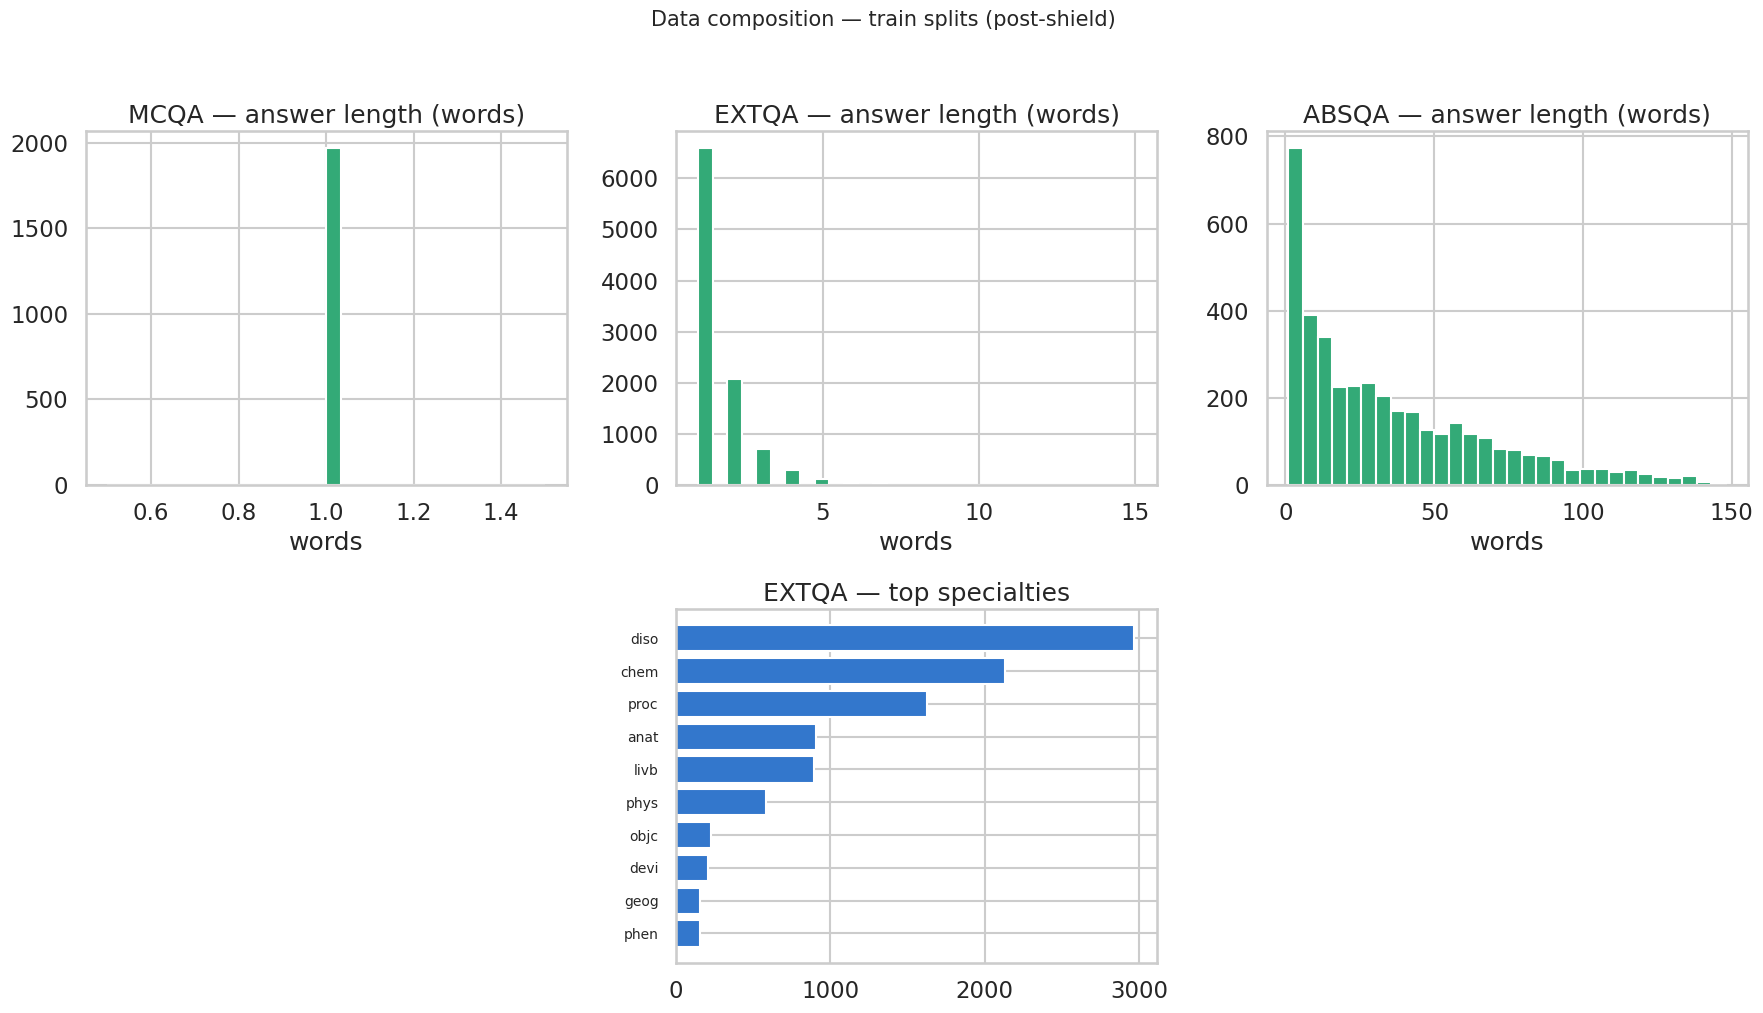

04:11:12 | I | ✓ Overview figure → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/data_overview.png


In [25]:
# ──────────────────────────────────────────────────────────────────────
# Stage 8b: Visualisations — answer-length histograms + specialty bars
# ──────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Data composition — train splits (post-shield)", fontsize=15, y=1.02)

for col, task in enumerate(["mcqa", "extqa", "absqa"]):
    sub = [r for r in train_rows if r["task"] == task]
    if not sub:
        axes[0, col].set_visible(False)
        axes[1, col].set_visible(False)
        continue
    # Top: answer length histogram
    lens = [len(str(r["answer"]).split()) for r in sub]
    axes[0, col].hist(lens, bins=30, color="#3a7", edgecolor="white")
    axes[0, col].set_title(f"{task.upper()} — answer length (words)")
    axes[0, col].set_xlabel("words")

    # Bottom: top specialties
    specs = [r.get("specialty") for r in sub if r.get("specialty")]
    if specs:
        top = Counter(specs).most_common(10)
        names, counts = zip(*top)
        axes[1, col].barh(range(len(names)), counts, color="#37c")
        axes[1, col].set_yticks(range(len(names)))
        axes[1, col].set_yticklabels(names, fontsize=10)
        axes[1, col].invert_yaxis()
        axes[1, col].set_title(f"{task.upper()} — top specialties")
    else:
        axes[1, col].set_visible(False)

plt.tight_layout()
fig_path = os.path.join(cfg.results_dir, "data_overview.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info(f"✓ Overview figure → {fig_path}")

## ✅ Stage 9 — Final validation gatesBefore NB2 reads these files, we assert:1. No row in `test.jsonl` appears (by leakage shield criterion) in train/val/exemplars.2. Every row has the unified schema fields.3. MCQA answers are non-empty letter strings, ExtQA spans appear in their context,   AbsQA answers are non-empty.If any assertion fails, NB1 raises and NB2 should not run.

In [26]:
# ──────────────────────────────────────────────────────────────────────
# Stage 9: Hard validation gates
# ──────────────────────────────────────────────────────────────────────
REQUIRED_FIELDS = {"id", "task", "question", "answer", "source"}

def _validate(rows, label):
    for i, r in enumerate(rows):
        missing = REQUIRED_FIELDS - set(r.keys())
        assert not missing, f"{label}[{i}] missing fields: {missing}"
        assert r["task"] in {"mcqa", "extqa", "absqa"}, \
            f"{label}[{i}] bad task: {r['task']}"
        assert isinstance(r["question"], str) and r["question"], \
            f"{label}[{i}] empty question"

_validate(train_rows,    "train")
_validate(val_rows,      "val")
_validate(test_rows,     "test")
_validate(exemplar_rows, "exemplars")
logger.info("✓ Schema validation passed")

# Task-specific sanity checks
for r in test_rows:
    if r["task"] == "mcqa":
        assert r["answer"], f"MCQA test row {r['id']} has empty answer"
        assert all(c.isalpha() and c.isupper() for c in r["answer"].replace(",", "")), \
            f"MCQA test row {r['id']} has bad letters: {r['answer']}"
    elif r["task"] == "extqa":
        assert r["context"] and r["answer"], \
            f"ExtQA test row {r['id']} missing context or answer"
        # Span should appear in context (best-effort, not enforced strictly)
        if r["answer"] not in r["context"]:
            # Try whitespace-normalised match
            norm_ctx = " ".join(r["context"].split())
            norm_ans = " ".join(r["answer"].split())
            if norm_ans not in norm_ctx:
                logger.warning(f"  ExtQA span not literally in context: {r['id']}")
    elif r["task"] == "absqa":
        assert r["answer"], f"AbsQA test row {r['id']} has empty answer"
logger.info("✓ Task-specific sanity passed")

# Final cross-shield assertion: re-run shield on a sample of train against test indices,
# expecting zero leakage now.
import random as _random_check
_rng_check = _random_check.Random(cfg.seed)
sample_n = min(500, len(train_rows))
sample = _rng_check.sample(train_rows, sample_n) if sample_n else []

leaks_in_clean = 0
for r in sample:
    if r["task"] == "mcqa":
        fp = _mcqa_fingerprint({"question": r["question"], "answers": r["options"] or {}})
        if ec.is_leaked(fp, lsh_mcqa, num_perm=cfg.minhash_num_perm):
            leaks_in_clean += 1
    elif r["task"] == "extqa":
        fp = _extqa_fingerprint({"question": r["question"],
                                 "answers": {"text": [r["answer"]]}})
        if ec.is_leaked(fp, lsh_extqa, num_perm=cfg.minhash_num_perm):
            leaks_in_clean += 1
    elif r["task"] == "absqa":
        fp = _absqa_fingerprint({"question": r["question"]})
        if ec.is_leaked(fp, lsh_absqa, num_perm=cfg.minhash_num_perm):
            leaks_in_clean += 1
assert leaks_in_clean == 0, (
    f"✗ Shield failure: {leaks_in_clean}/{len(sample)} train rows still match test!"
)
logger.info(f"✓ Cross-shield: 0 leaks in {len(sample)}-row train sample")

04:11:22 | I | ✓ Schema validation passed
04:11:22 | I | ✓ Task-specific sanity passed
04:11:23 | I | ✓ Cross-shield: 0 leaks in 500-row train sample


## 📤 Stage 10 — Upload artifacts to HF Hub (optional)Pushes `train/val/test/exemplars` as a private dataset under`{HF_USER}/EnToFrMedicaLLM-data`. Skipped if no HF_TOKEN.

In [27]:
# ──────────────────────────────────────────────────────────────────────
# Stage 10: Upload data artifacts to HF Hub as a private dataset
# ──────────────────────────────────────────────────────────────────────
if HF_TOKEN:
    try:
        from huggingface_hub import HfApi, create_repo

        repo_id = f"{HF_USER}/{cfg.project_name}-data"
        create_repo(repo_id, repo_type="dataset", private=True,
                    exist_ok=True, token=HF_TOKEN)
        api = HfApi(token=HF_TOKEN)
        for name, path in paths.items():
            api.upload_file(
                path_or_fileobj=path, path_in_repo=os.path.basename(path),
                repo_id=repo_id, repo_type="dataset",
            )
        # Plus the leakage report + stats
        for f in ["leakage_report.json", "data_stats.json", "data_overview.png"]:
            local = os.path.join(cfg.results_dir, f)
            if os.path.exists(local):
                api.upload_file(path_or_fileobj=local, path_in_repo=f,
                                repo_id=repo_id, repo_type="dataset")
        logger.info(f"✓ Pushed to https://huggingface.co/datasets/{repo_id}")
    except Exception as e:
        logger.error(f"HF upload failed (non-fatal): {e}")
else:
    logger.info("• Skipping HF upload (no token)")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../RESULT/data_overview.png: 100%|##########|  136kB /  136kB            

No files have been modified since last commit. Skipping to prevent empty commit.


04:12:10 | I | ✓ Pushed to https://huggingface.co/datasets/boods/EnToFrMedicaLLM-data


## 🏁 Stage 11 — Done. NB2 can now consume these artifacts.**Outputs in `cfg.results_dir`:**- `train.jsonl` — SFT training data (mixed tasks)- `val.jsonl` — validation- `test.jsonl` — Golden Test Set (locked)- `exemplars.jsonl` — few-shot pool- `dapt_corpus_sample.jsonl` — sample from PARCOMED + CAS (NB2 will stream the full set)- `leakage_report.json` — what the shield caught (paper appendix material)- `data_stats.json` — per-task descriptive statistics- `data_overview.png` — exploratory figures**Next:** open NB2 (`NB2_DAPT.ipynb`) — it loads `dapt_corpus_sample.jsonl` for asanity preview and streams the full PARCOMED for actual training.

In [28]:
# ──────────────────────────────────────────────────────────────────────
# Stage 11: Final summary banner
# ──────────────────────────────────────────────────────────────────────
print("\n" + "═" * 70)
print(f"  NB1 COMPLETE — {ec.now_ts()}")
print("═" * 70)
print(f"  train.jsonl     : {len(train_rows):>7,} rows")
print(f"  val.jsonl       : {len(val_rows):>7,} rows")
print(f"  test.jsonl      : {len(test_rows):>7,} rows  ← locked Golden Test Set")
print(f"  exemplars.jsonl : {len(exemplar_rows):>7,} rows  (per-task pool)")
print(f"  Leakage filtered: {sum([len(mcqa_train_leaks), len(extqa_train_leaks), len(absqa_train_leaks)]):>7,} rows")
print("═" * 70)
print("  → Proceed to NB2_DAPT.ipynb for domain-adaptive pre-training.")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  NB1 COMPLETE — 20260505_041236
══════════════════════════════════════════════════════════════════════
  train.jsonl     :  15,766 rows
  val.jsonl       :   1,155 rows
  test.jsonl      :   1,077 rows  ← locked Golden Test Set
  exemplars.jsonl :     600 rows  (per-task pool)
  Leakage filtered:   2,283 rows
══════════════════════════════════════════════════════════════════════
  → Proceed to NB2_DAPT.ipynb for domain-adaptive pre-training.
══════════════════════════════════════════════════════════════════════
